### Method
Using agentic workflow to categorize bank transactions


1. use monoply to process the pdfs into csv
2. merge csvs into one
3. use llm to work parallely to categorize our transactions [only to categorize] with reviewer LLM to check if input length is correct.
4. if unknown then we use a researcher agent -> We clean using regex then duck duck go search to gather context for unknown lines + RAG and call LLM agent for each uncertain entry => Could probably save on token by doing in batch lol
4. manually tableau later

this can be improved. relatively slow output speed

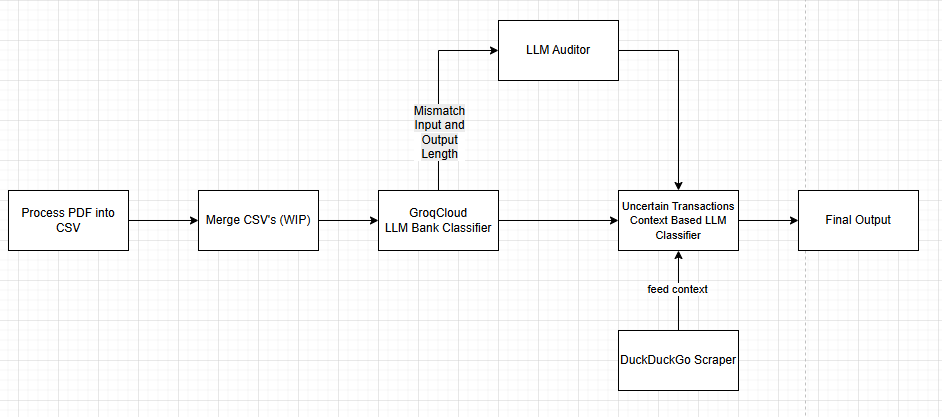

### Initialize Functions

In [335]:
import os
import subprocess
import regex as re
import pandas as pd
import requests
from bs4 import BeautifulSoup
from dotenv import load_dotenv
from pydantic_ai import Agent
from pydantic_ai.models.groq import GroqModel
from pydantic_ai.providers.groq import GroqProvider


#Load .env and check if API Key Loaded
load_dotenv()
GROQ_API_KEY = os.getenv("GROQ_API_KEY")
assert GROQ_API_KEY is not None, "GROQ_API_KEY environment variable not set"

# Processes our ~pdfs
def process_pdf():
    subprocess.run(["monopoly", ".", '--preserve-filename'])
    return 'Finished Processing PDFs'

# DuckDuckGo Scraper
def ddg_scrape(query, max_results=5):
    url = "https://duckduckgo.com/html/"
    params = {
        "q": query + " SG",
        "kl": "sg-en"
    }
    headers = {
        "User-Agent": "Mozilla/5.0"
    }

    res = requests.get(url, params=params, headers=headers)
    soup = BeautifulSoup(res.text, "html.parser") #[parser]

    results = []

    for result in soup.select(".result"):
        title_tag = result.select_one(".result__a")
        snippet_tag = result.select_one(".result__snippet")

        if title_tag:
            title = title_tag.get_text()
            snippet = snippet_tag.get_text() if snippet_tag else ""
            results.append({
                "title": title,

                "snippet": snippet
            })
        if len(results) >= max_results:
            break
    return results

# Line Cleaner for DuckDuckGo and Context based LLM
def clean_line(line):
    line = line.replace("FAST PAYMENT via PayNow-Mobile", "")
    line = line.replace("FAST PAYMENT via PayNow-QR", "")
    line = line.replace("FAST PAYMENT via PayNow-UEN to ", "")
    line = line.replace("PAYMENT/TRANSFER DBSS from ", "")  
    line = line.replace("PAYMENT/TRANSFER OCBC from ", "")  
    line = line.replace("PAYMENT/TRANSFER UOB from ", "")  
    line = line.replace("PAYMENT/TRANSFER HSBC from ", "")  
    line = line.replace("PAYMENT/TRANSFER MAYBANK from ", "")
    line = line.replace("PAYMENT/TRANSFER CIMB from ", "")
    line = line.replace("PAYMENT/TRANSFER STANDARD CHARTERED from ", "")
    line = line.replace("PAYMENT/TRANSFER DBS from ", "")
    line = line.replace("PAYMENT/TRANSFER POSB from ", "")
    line =  re.sub(r'^.*?NETS QR PURCHASE\s+', '', line)
    line = re.sub(r'DEBIT PURCHASE \d{2}/\d{2}/\d{2} [xX]{2}-\d{4}', '', line)
    line = re.sub(r'CARD PURCHASE \d{2}/\d{2}/\d{2} [xX]{2}-\d{4}', '', line)
    line = re.sub(r'CREDIT PURCHASE \d{2}/\d{2}/\d{2} [xX]{2}-\d{4}', '', line)
    line = re.sub(r'POS PURCHASE.*?xx-\d+\s*', '', line)
    line = re.sub(r'OTHR-.*$', '', line)
    return line.strip()


# Mismatch output length checker
def check_output_length(original_input, ai_output):
    if len(original_input) != len(ai_output.split(',')):
        return "Incorrect"
    return "Correct"

# LLM Models
# First Classifier
model = GroqModel(
    #'openai/gpt-oss-120b', provider=GroqProvider(api_key=GROQ_API_KEY) #Smaller Model
    'moonshotai/kimi-k2-instruct', provider=GroqProvider(api_key=GROQ_API_KEY)
)
agent = Agent(
    model,
    system_prompt=(
        "You are a Singapore-based bank transaction classifier. "
        "Task: Categorize each transaction into: Food, Utilities, Transport, Healthcare, Shopping, Travel, PAYNOW OUT, PAYNOW IN, Salary, Other, Uncertain. "

        "Classification Rules (Priority Order): "
        "1. Transport: GRAB (non-food), GOJEK, COMFORTDELGRO, TRANSITLINK, SGBIKE, SIMPLYGO, EZ-LINK. "
        "2. Food: Restaurants, cafes, food courts, fast food(McDonalds,KFC,Stuff'd,Dabba Street), delivery (GrabFood, FoodPanda), and merchants with food-related keywords like 'Eat', 'F&B', 'CAFE', 'EATERY', or 'COFFEE'."
        "3. Utilities: Telcos (Singtel, StarHub, M1, GOMO, SIMBA, VIVIFI), SP Group, and recurring bills. "
        "4. Healthcare: Clinics, hospitals, and pharmacies (e.g., Guardian, Watsons). "
        "5. Shopping: Supermarkets (NTUC, Cold Storage, Sheng Siong, Donki), e-commerce (Shopee, Lazada, Amazon), retail stores, fitness merchants (Anytime Fitness) and entertainment (KTV, Skating, Arcades like TIMEZONE, COWPLAY COW MOO) "
        "6. Travel: Airlines, hotels, travel agencies and online booking platforms (e.g., Expedia, Booking.com, Trip, Agoda). "
        "7. PAYNOW OUT: For money leaving the account to a PRIVATE INDIVIDUAL (e.g., 'PAYNOW TO ALEXANDRA T'). Only use this if it does not match a merchant business. "
        "8. PAYNOW IN: For money entering the account from a PRIVATE INDIVIDUAL (e.g., 'PAYNOW FROM WEI JIE'). Includes miscellaneous incoming transfers that are NOT salary. "
        "9. Salary: All 'GIRO - SALARY' records or large monthly recurring employer credits."
        "10. Other: Use this for non-merchant financial entries that do not involve another person. Includes: "
        " - Investments/Insurance: Monthly premiums (e.g., Prudential, AIA), brokerage deposits (e.g., Tiger, Moomoo, IBKR)."
        " - Government/Tax: IRAS tax payments, CPF contributions, or government payouts (GST Vouchers)."
        " - Bank Adjustments: Cashbacks, interest earned, or internal account-to-account transfers within the same bank."
        " - Digital wallet top-ups (REVOLUT, YOUTRIP, WISE, GRABPAY). "
        " - Bank fees and interest charges. "
        "11. Uncertain: Use this for ambiguous codes, generic UENs, or any merchant where confidence is <95%. "

        "Output Format: "
        "- Strictly output ONLY the category names. "
        "- Maintain the input order. "
        "- Separate by commas (no spaces). "
        "- DO NOT include explanations or extra text. "

        "Example: "
        "Input: GRAB* 1234|REVOLUT TOPUP|NTUC FAIRPRICE|PAYNOW TO DAN "
        "Output: Transport,Other,Shopping,Other"
    )
)

# Auditor 
reviewer_model = GroqModel(
    #'openai/gpt-oss-120b', provider=GroqProvider(api_key=GROQ_API_KEY)
    
    'moonshotai/kimi-k2-instruct', provider=GroqProvider(api_key=GROQ_API_KEY)
)
reviewer_agent = Agent(
    reviewer_model,
   system_prompt=(
        "You are a Singapore-based Data Integrity Auditor. "
        "Your sole mission is to ensure a 1:1 mapping between transactions and categories. "
        "These are the categories:  Food, Utilities, Transport, Healthcare, Shopping, Travel, PAYNOW OUT, PAYNOW IN, Salary, Other, Uncertain. "
        "REFERENCE CLASSIFICATION STANDARDS (Priority Order):"
        "1. Transport: All ride-hailing (GRAB, GOJEK) and public transit (SIMPLYGO, EZ-LINK)."
        "2. Food: All dining, cafes, and delivery. Key triggers: 'BREW', 'CAFE', 'EATERY', 'COFFEE', 'GrabFood'."
        "3. Utilities: All SG Telcos (Singtel, StarHub, M1, GOMO, SIMBA) and SP Group."
        "4. Healthcare: Medical clinics, hospitals, and pharmacies (Guardian/Watsons)."
        "5. Shopping: Supermarkets (NTUC, Donki), E-commerce (Shopee/Lazada), Fitness (Anytime Fitness), and Entertainment (KTV/Arcade)."
        "6. Travel: Airlines, Hotels, and Booking sites (Expedia/Agoda)."
        "7. PAYNOW OUT: For money leaving the account to a PRIVATE INDIVIDUAL (e.g., 'PAYNOW TO ALEXANDRA T'). Only use this if it does not match a merchant business. "
        "8. PAYNOW IN: For money entering the account from a PRIVATE INDIVIDUAL (e.g., 'PAYNOW FROM WEI JIE'). Includes miscellaneous incoming transfers that are NOT salary. "
        "9. Salary: All 'GIRO - SALARY' records or large monthly recurring employer credits."
        "10. Other: Use this for non-merchant financial entries that do not involve another person. Includes: "
        " - Investments/Insurance: Monthly premiums (e.g., Prudential, AIA), brokerage deposits (e.g., Tiger, Moomoo, IBKR)."
        " - Government/Tax: IRAS tax payments, CPF contributions, or government payouts (GST Vouchers)."
        " - Bank Adjustments: Cashbacks, interest earned, or internal account-to-account transfers within the same bank."
        " - Digital wallet top-ups (REVOLUT, YOUTRIP, WISE, GRABPAY). "
        " - Bank fees and interest charges. "
        "11. Uncertain: Use this for ambiguous codes, generic UENs, or any merchant where confidence is <95%. "

        "Input Analysis: "
        "You will receive a list formatted as: 'Transaction Description' -> 'Attempted Category'. "
        
        "RECONCILIATION RULES: "
        "1. ALIGNMENT: Every transaction MUST have exactly one category. "
        "2. CORRECTION: If 'Attempted Category' is [MISSING] or [INCORRECT], assign the correct category based on Singapore merchant rules. "
        "3. TRIMMING: If there are extra categories provided that do not have a corresponding transaction, DISCARD them immediately. "
        "4. PRESERVATION: If the 'Attempted Category' is already correct, do not change it. "

        "STRICT OUTPUT: "
        "- Output ONLY the final category names. "
        "- Format: Comma-separated, no spaces, no trailing commas. "
        "- The number of categories in your output MUST exactly match the number of input transactions."
    )
)

def correction_prompt(original_input, ai_output):
    return (
        f"The original input had {len(original_input)} transactions, but the AI output {len(ai_output)} categories. Please correct the output to have exactly {len(original_input)} categories, strictly following the rules and format. Only output the corrected comma-separated categories without any explanations or extra text."
        f"These are the original transactions: {original_input} and the AI's assigned categories: {ai_output}."
    )

# Research
researcher_agent = GroqModel(
    'openai/gpt-oss-20b', provider=GroqProvider(api_key=GROQ_API_KEY)
)

researcher_agent = Agent(
    reviewer_model,
    system_prompt=(
        "You are a Merchant Intelligence Researcher. "
        "Your task: Analyze scraped data to identify a merchant's primary business. "
        
        "RULES: "
        "1. Identify the core 'Category' from: Food, Utilities, Transport, Healthcare, Shopping, Travel, PAYNOW OUT, PAYNOW IN, Salary, Other, Uncertain."
        "2. If the data mentions food, beverages, dining, or cafes (e.g., 'Brew', 'Roast', 'Rice'), prioritize **Food**. "
        "3. If the data is ambiguous, output **Uncertain**."
    
        "Output Format: Strictly the Category name."
        "DO NOT GUESS."
    )
)

def research_prompt(info):
    return (
        f"{info}"
    )

# Run Model Functions
async def run_agent(agent,li: str):
    result = await agent.run(li)
    return result.output

async def classify_transactions(transactions): #df['description]
    c = 10 # chunk size
    all = []
    for i in range(0, len(transactions), c):
        trans_sliced = transactions[i:i+c]
        li = ' | '.join(trans_sliced.tolist()) # creates list
        try:
            output = await run_agent(agent,li)
            cleaned = [x.strip() for x in output.split(',')]
            if check_output_length(trans_sliced,output) == 'Incorrect':
                print("Output length incorrect, running reviewer agent...")
                reviewed =  await run_agent(reviewer_agent, correction_prompt(trans_sliced.to_list() , cleaned))
                reviewed_list = [x.strip() for x in reviewed.split(',')]
                print('Agent-Reviewed Output:', reviewed_list)
                all.extend(reviewed_list)
            else:
                all.extend(cleaned)
                print('Non Agent-Reviewed Output:', cleaned)
        except Exception as e:
            print('Error', e)
    return all

## For uncertain entries, create a master key list of the merchants by cleaning each line -> Use a set so same merchants dont have to be repeated. Then categorise accordingly and reset.
# Create master key list then category then reassign -> so df2 has the key:category then we search thru this and assign
async def key_list(df):
    li = []
    li2 = []
    dic = {}
    df_tag  = df[df['Tag'] == 'Uncertain']['description']
    for i in df_tag.to_list():
        try:     
            res = clean_line(i)
            if res not in li:
                li.append(res)
                scrape = ddg_scrape(res)
                print(scrape)
                o = await researcher_agent.run(research_prompt(scrape))
                dic[res] = o.output.strip().replace("\n", "")
        except Exception as e:
            print(e)
    # After creating the master dict
    for i in df_tag.to_list():
        cl = clean_line(i)
        li2.append(dic[cl])
    print(dic)
    mask = df['Tag'] == 'Uncertain'
    df.loc[mask, 'Tag'] = li2
    return df

# Final function, can just call this
async def final_classification_function(df):
    tags =  await classify_transactions(df['description'])
    df['Tag'] = tags
    final_df = await key_list(df)
    return final_df

In [3]:
process_pdf()

'Finished Processing PDFs'

In [306]:
df = pd.read_csv('dec.csv')

In [268]:
df2 = df[0:10]

In [ ]:
every =  await final_classification_function(df)

In [313]:
every.to_csv('test.csv')

In [315]:
df['description'].to_list()

['FAST PAYMENT via PayNow-Mobile to fangyi OTHR-OTHR',
 'DEBIT PURCHASE 01/12/25 xx-3497 247 FITNESS SINGAPORE S',
 'PAYMENT/TRANSFER DBSS from Alexandra Tole OTHR REVTRN25120413102443907',
 'POS PURCHASE NETS SIMPLYGO xx-1491 SIMPLYGO PTE. LTD A',
 'FAST PAYMENT via PayNow-Mobile to ABDUL FAIZ BIN A OTHR-OTHR',
 'PAYMENT/TRANSFER via PayNow-SSPI from TOLENTINO ALEX OTHR From Tolentino Alexandra Mora',
 'COLLECTION/TRANSFER OTHR REVOLUT TECHNO REVOLUTEGIRO2023071 REVDDT25120513121613081',
 'FAST PAYMENT via PayNow-Mobile to ABDUL FAIZ BIN A OTHR-OTHR',
 'FAST PAYMENT via PayNow-UEN to XING YUN EATING OTHR-EPOSSPS5OPO22HMAUAI1 V7',
 'FUND TRANSFER via PayNow-QR Code to LA-TEH CAFE PRIV OTHR - OTHR',
 'PAYMENT/TRANSFER via PayNow-DBSS from KE EE CHONG OTHR PayNow transfer',
 'POS PURCHASE NETS TIMEZONE S xx-1491 TIMEZONE SINGAPOR T',
 'PAYMENT/TRANSFER via PayNow-DBSS from ABNER MAGNO TO OTHR PayNow transfer',
 'FAST PAYMENT via PayNow-UEN to Qashier-555 OTHR-qsb-sqr-sg-382408149 042',
 

In [294]:
import pandas as pd
import matplotlib.pyplot as plt

In [328]:
every2= every[every['amount'] < 0]

In [329]:
every3= every[every['amount'] > 0]

In [330]:
every

,date,description,amount,balance,Tag
0,2025-11-30,FAST PAYMENT via PayNow-Mobile to fangyi OTHR-...,-5.00,194.14,PAYNOW OUT
1,2025-12-03,DEBIT PURCHASE 01/12/25 xx-3497 247 FITNESS SI...,-98.00,96.14,Shopping
2,2025-12-04,PAYMENT/TRANSFER DBSS from Alexandra Tole OTHR...,81.00,177.14,PAYNOW IN
3,2025-12-04,POS PURCHASE NETS SIMPLYGO xx-1491 SIMPLYGO PT...,-81.00,96.14,Transport
4,2025-12-05,FAST PAYMENT via PayNow-Mobile to ABDUL FAIZ B...,-20.70,75.44,PAYNOW OUT
...,...,...,...,...,...
75,2025-12-30,FUND TRANSFER via PayNow-QR Code to FOMO PAY P...,-15.00,128.79,Other
76,2025-12-30,CASH DEPOSIT CDM xx-1491 OCBC-WHITE SANDS S,250.00,378.79,Other
77,2025-12-30,CASH DEPOSIT CDM xx-1491 OCBC-WHITE SANDS S,18.00,396.79,Other
78,2025-12-31,COLLECTION/TRANSFER OTHR REVOLUT TECHNO REVOLU...,-50.00,346.79,Other


In [334]:
every2['Tag'].unique()

array(['PAYNOW OUT', 'Shopping', 'Transport', 'Other', 'Food',
       '\n\nShopping', '\n\nOther', 'Utilities', '\n\nFood'], dtype=object)

<Axes: ylabel='amount'>

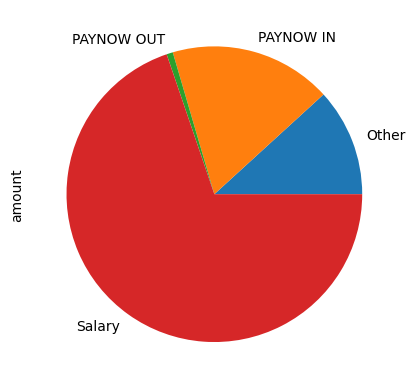

In [331]:
every3.groupby('Tag')['amount'].sum().plot(kind='pie')

In [332]:
every2['amount'] = every2['amount'].abs()

C:\Users\shiro\AppData\Local\Temp\ipykernel_16488\3951294495.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  every2['amount'] = every2['amount'].abs()


<Axes: ylabel='amount'>

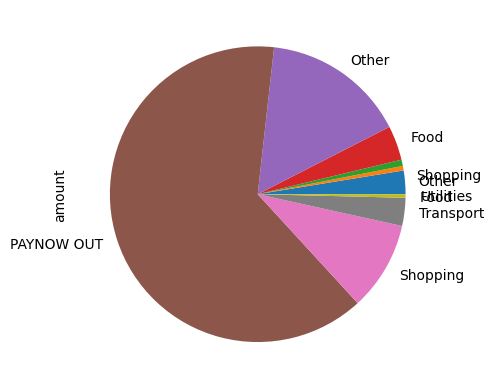

In [333]:
every2.groupby('Tag')['amount'].sum().plot(kind='pie')